In [26]:
#Phase 1: Data Collection and Exploratory Data Analysis (EDA)


In [27]:
#Step 1 - Data Import and Preprocessing


In [28]:
import pandas as pd
path = "E:\download\Food_Delivery_Time_Prediction.csv"
df= pd.read_csv(path)
print(df.head(5))
print(df.info())
print(df.isnull().sum())

  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [29]:
#Data Transformation
                       # (a) Encode Categorical Variables
from sklearn.preprocessing import OneHotEncoder

df_onehot_encoded = pd.get_dummies(df, columns=['Weather_Conditions', 'Traffic_Conditions','Vehicle_Type','Order_Priority',], drop_first=True)

print(f"One-Hot Encoded Data using Pandas:\n{df_onehot_encoded.head()}\n")


One-Hot Encoded Data using Pandas:
  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

   Delivery_Person_Experience Order_Time  Restaurant_Rating  Customer_Rating  \
0                           4  Afternoon                4.1              3.0   
1                           8      Night                4.5              4.2   
2                           9      Night                3.3              3.4   
3                           2    Evening                3.2              3.7   
4                           6      Night                3.5              2.8   

   Delivery_Time  Order_Cost  Tip_Amount  Weather_C

In [30]:
#(b) Normalize/Standardize Numeric Columns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Distance', 'Delivery_Time', 'Order_Cost']] = scaler.fit_transform(
    df[['Distance', 'Delivery_Time', 'Order_Cost']])
print(df.head())

  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083) -1.454738   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)  1.439192   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482) -0.666417   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)  0.335835   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182) -0.700119   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [31]:
#Calculate the basic statistics for numerical features such as mean, median, mode, and variance
df= pd.read_csv(path)

mean_values = df.mean(numeric_only=True)
print("Mean:\n", mean_values)

median_values = df.median(numeric_only=True)
print("Median:\n", median_values)

mode_values = df.mode(numeric_only=True)
print("Mode:\n", mode_values)

variance_values = df.var(numeric_only=True)
print("Variance:\n", variance_values)

Mean:
 Distance                        11.49805
Delivery_Person_Experience       5.25000
Restaurant_Rating                3.73850
Customer_Rating                  3.68650
Delivery_Time                   70.49495
Order_Cost                    1046.48870
Tip_Amount                      46.61665
dtype: float64
Median:
 Distance                        10.265
Delivery_Person_Experience       5.000
Restaurant_Rating                3.800
Customer_Rating                  3.700
Delivery_Time                   72.775
Order_Cost                    1035.950
Tip_Amount                      47.530
dtype: float64
Mode:
    Distance  Delivery_Person_Experience  Restaurant_Rating  Customer_Rating  \
0      1.32                         8.0                3.8              2.6   
1      3.25                         NaN                NaN              3.4   
2      4.33                         NaN                NaN              NaN   
3      6.09                         NaN                NaN             

In [32]:
# 2 Correlation Analysis
import pandas as pd
df= pd.read_csv(path)
# Only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Delivery_Time ke saath correlation
delivery_corr = corr_matrix["Delivery_Time"].sort_values(ascending=False)

print(delivery_corr)



Delivery_Time                 1.000000
Order_Cost                   -0.009307
Delivery_Person_Experience   -0.019098
Customer_Rating              -0.021952
Tip_Amount                   -0.029154
Distance                     -0.075143
Restaurant_Rating            -0.091855
Name: Delivery_Time, dtype: float64


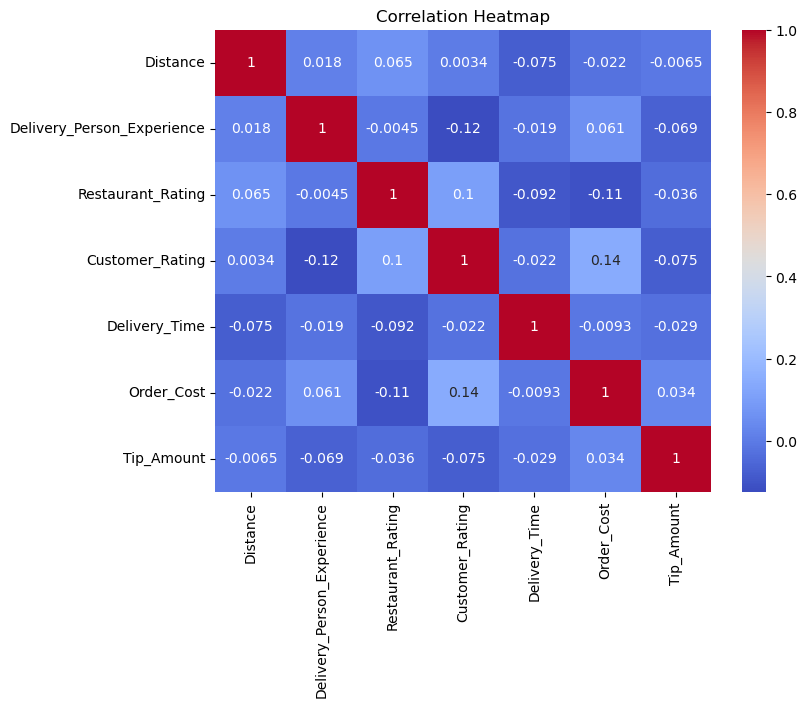

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

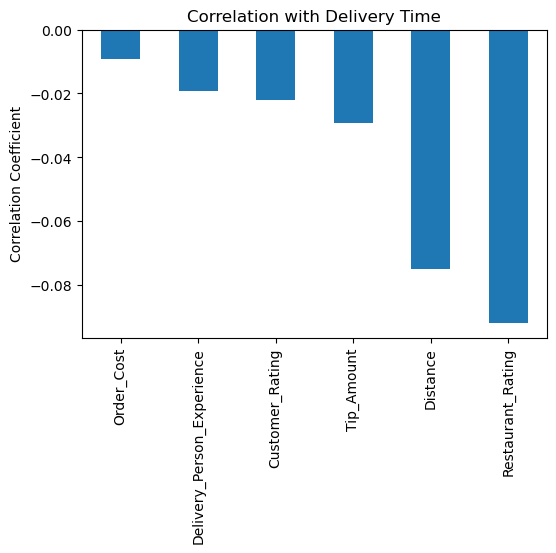

In [34]:
plt.figure(figsize=(6,4))
delivery_corr.drop("Delivery_Time").plot(kind="bar")
plt.title("Correlation with Delivery Time")
plt.ylabel("Correlation Coefficient")
plt.show()

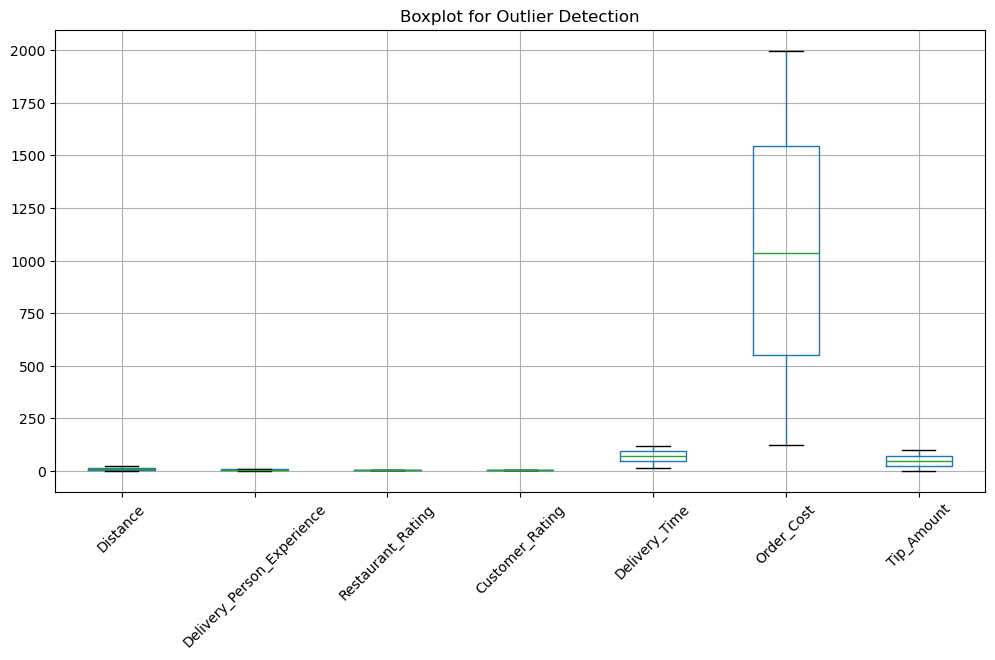

In [35]:
#Outlier Detection
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [36]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numeric_cols] > (Q3 + 1.5 * IQR)))

print("Number of Outliers per Column:\n")
print(outliers.sum())

Number of Outliers per Column:

Distance                      0
Delivery_Person_Experience    0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [37]:
#Step 3 - Feature Engineering

In [38]:
#Distance Calculation
import numpy as np

# Remove brackets if present
df["Customer_Location"] = df["Customer_Location"].str.replace("(", "").str.replace(")", "")
df["Restaurant_Location"] = df["Restaurant_Location"].str.replace("(", "").str.replace(")", "")

# Split latitude & longitude
df[["Customer_Latitude", "Customer_Longitude"]] = df["Customer_Location"].str.split(",", expand=True)
df[["Restaurant_Latitude", "Restaurant_Longitude"]] = df["Restaurant_Location"].str.split(",", expand=True)

# Convert to float
df["Customer_Latitude"] = df["Customer_Latitude"].astype(float)
df["Customer_Longitude"] = df["Customer_Longitude"].astype(float)
df["Restaurant_Latitude"] = df["Restaurant_Latitude"].astype(float)
df["Restaurant_Longitude"] = df["Restaurant_Longitude"].astype(float)

print(df.head())

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, 
                                 [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + \
        np.cos(lat1) * np.cos(lat2) * \
        np.sin(dlon/2)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df["Calculated_Distance"] = haversine(
    df["Restaurant_Latitude"],
    df["Restaurant_Longitude"],
    df["Customer_Latitude"],
    df["Customer_Longitude"]
)

print(df["Calculated_Distance"].head())
    

  Order_ID     Customer_Location   Restaurant_Location  Distance  \
0  ORD0001  17.030479, 79.743077  12.358515, 85.100083      1.57   
1  ORD0002  15.398319, 86.639122  14.174874, 77.025606     21.32   
2  ORD0003  15.687342, 83.888808  19.594748, 82.048482      6.95   
3  ORD0004  20.415599, 78.046984  16.915906, 78.278698     13.79   
4  ORD0005  14.786904, 78.706532  15.206038, 86.203182      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1              3.0   
1   

In [39]:
print(df.columns)


Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount', 'Customer_Latitude', 'Customer_Longitude',
       'Restaurant_Latitude', 'Restaurant_Longitude', 'Calculated_Distance'],
      dtype='object')


In [40]:
#Time-Based Features


df["Rush_Hour"] = df["Order_Time"].isin(["Afternoon", "Evening"]).astype(int)
# Then encoding
df = pd.get_dummies(df, columns=["Order_Time"], drop_first=True)
print(df["Rush_Hour"].head(10))

      


0    1
1    0
2    0
3    1
4    0
5    1
6    1
7    1
8    0
9    1
Name: Rush_Hour, dtype: int64


In [46]:
#Step 4 - Linear Regression Model
from sklearn.model_selection import train_test_split
df = pd.read_csv(path)
df['Traffic_Conditions'] = df['Traffic_Conditions'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
})

df['Order_Priority'] = df['Order_Priority'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

X = df[['Distance','Traffic_Conditions','Order_Priority',
        'Restaurant_Rating','Customer_Rating']]
y = df["Delivery_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 5)
X_test shape: (40, 5)
y_train shape: (160,)
y_test shape: (40,)


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 901.1820094400942
Mean Absolute Error (MAE): 25.308663108160278
R-squared (R²): 0.02563458248438244


In [51]:
df['Delivery_Status'] = df['Delivery_Time'].apply(
    lambda x: 0 if x <= 30 else 1
)

X = df[['Traffic_Conditions',
        'Weather_Conditions',
        'Delivery_Person_Experience',
        'Distance',
        'Order_Priority']]

y = df['Delivery_Status']

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.45
Precision: 0.8
Recall: 0.47058823529411764
F1-score: 0.5925925925925926
Confusion Matrix:
 [[ 2  4]
 [18 16]]


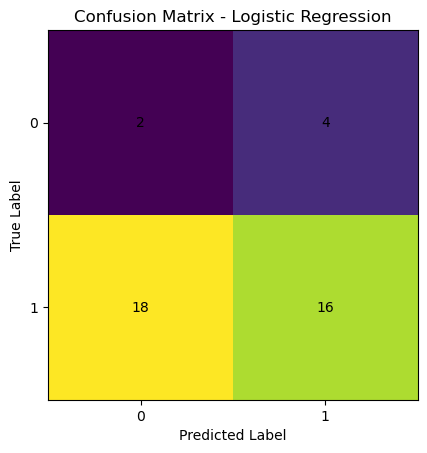

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predictions
y_pred_log = log_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0,1])
plt.yticks([0,1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

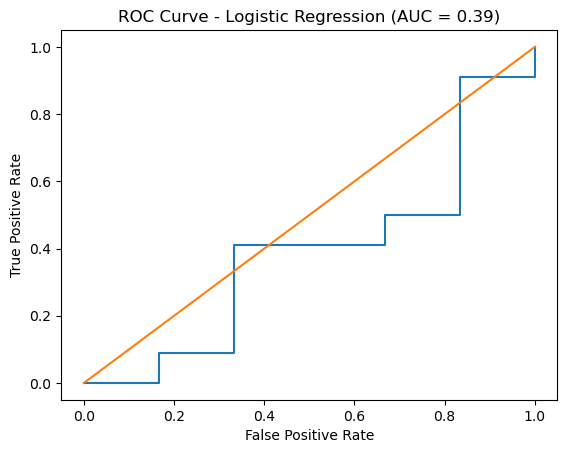

In [60]:
from sklearn.metrics import roc_curve, auc

y_prob_log = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve - Logistic Regression (AUC = %.2f)" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()